Dataset 0: Optimized params - min_samples=2, eps=0.050
Dataset 0, MiniBatch
KMeans: Silhouette = 0.3453, Davies-Bouldin = 1.1981
Dataset 0, Affinity
Propagation: Silhouette = 0.3850, Davies-Bouldin = 0.8424
Dataset 0, MeanShift: Silhouette = 0.3800, Davies-Bouldin = 0.8506
Dataset 0, Spectral
Clustering: Silhouette = 0.1138, Davies-Bouldin = 240.5861
Dataset 0, Ward: Silhouette = 0.3463, Davies-Bouldin = 1.1980
Dataset 0, Agglomerative
Clustering: Silhouette = 0.2528, Davies-Bouldin = 1.7437
Dataset 0, OPTICS: Silhouette = 0.1138, Davies-Bouldin = 240.5861
Dataset 0, BIRCH: Silhouette = 0.3197, Davies-Bouldin = 1.2387
Dataset 0, Gaussian
Mixture: Silhouette = 0.3466, Davies-Bouldin = 1.1987
Dataset 0, DBSCAN: Silhouette = 0.1138, Davies-Bouldin = 240.5861
Dataset 0, FADBSCAN: Silhouette = 0.7038, Davies-Bouldin = 0.3009
Dataset 1: Optimized params - min_samples=6, eps=0.050
Dataset 1, MiniBatch
KMeans: Silhouette = 0.4958, Davies-Bouldin = 0.8117
Dataset 1, Affinity
Propagation: Silhou

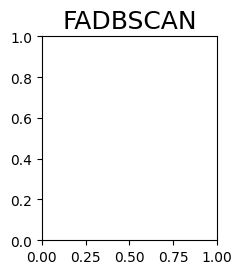

In [1]:
import time
import warnings
from itertools import cycle, islice

import matplotlib.pyplot as plt
import numpy as np

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score  # Missing import
from sklearn.metrics import silhouette_score, davies_bouldin_score


def firefly_algorithm(num_fireflies, num_dimensions, max_generations, X, beta=1.0, alpha=0.2):
    # Initialize fireflies
    fireflies = np.random.rand(num_fireflies, num_dimensions)
    fireflies[:, 0] = 2 + fireflies[:, 0] * 18   # min_samples: 2-20
    fireflies[:, 1] = 0.05 + fireflies[:, 1] * 1.95  # eps: 0.05-2.0 (FIXED)

    best_firefly = None
    best_fitness = -np.inf

    for generation in range(max_generations):
        fitness = np.zeros(num_fireflies)

        for i in range(num_fireflies):
            min_samples = int(fireflies[i, 0])
            eps = fireflies[i, 1]

            try:
                dbscan = cluster.DBSCAN(eps=eps, min_samples=min_samples)
                labels = dbscan.fit_predict(X)

                if len(np.unique(labels)) > 1 and np.sum(labels != -1) > 1:
                    non_noise_mask = labels != -1
                    if np.sum(non_noise_mask) > 1:
                        # Paper's fitness function
                        sil = silhouette_score(X[non_noise_mask], labels[non_noise_mask])
                        dbi = davies_bouldin_score(X[non_noise_mask], labels[non_noise_mask])
                        noise_ratio = np.sum(labels == -1) / len(labels)

                        # F = 0.5*SC - 0.5*DBI - 0.2*noise
                        fitness[i] = 0.5 * sil - 0.5 * dbi - 0.2 * noise_ratio
                    else:
                        fitness[i] = -2
                else:
                    fitness[i] = -2
            except:
                fitness[i] = -2

        # Move fireflies (add movement logic)
        for i in range(num_fireflies):
            for j in range(num_fireflies):
                if fitness[j] > fitness[i]:
                    distance = np.linalg.norm(fireflies[i] - fireflies[j])
                    if distance > 0:
                        attractiveness = beta * np.exp(-distance ** 2)
                        fireflies[i, 0] += attractiveness * (fireflies[j, 0] - fireflies[i, 0]) + alpha * (np.random.rand() - 0.5)
                        fireflies[i, 1] += attractiveness * (fireflies[j, 1] - fireflies[i, 1]) + alpha * (np.random.rand() - 0.5)
                        fireflies[i, 0] = np.clip(fireflies[i, 0], 2, 20)
                        fireflies[i, 1] = np.clip(fireflies[i, 1], 0.05, 2.0)
                        fireflies[i, 0] = int(fireflies[i, 0])

        # Update best solution
        current_best_idx = np.argmax(fitness)
        if fitness[current_best_idx] > best_fitness:
            best_fitness = fitness[current_best_idx]
            best_firefly = fireflies[current_best_idx].copy()

    return best_firefly

# ============
# Generate datasets
# ============
n_samples = 500
seed = 30
noisy_circles = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=seed)
rng = np.random.RandomState(seed)
no_structure = rng.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(9 * 2 + 3, 13))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 3,
    "n_clusters": 3,
    "min_samples": 7,
    "xi": 0.05,
    "min_cluster_size": 0.1,
    "allow_single_cluster": True,
    "random_state": 42,
}

datasets_list = [  # Changed variable name to avoid conflict
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.08,
        },
    ),
    (
        noisy_moons,
        {
            "damping": 0.75,
            "preference": -220,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.1,
        },
    ),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.01,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {"min_samples": 7, "xi": 0.1, "min_cluster_size": 0.2}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets_list):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)

    # estimate bandwidth for mean shift
    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

    # ============
    # Create cluster objects
    # ============
    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    two_means = cluster.MiniBatchKMeans(
        n_clusters=params["n_clusters"],
        random_state=params["random_state"],
    )
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
    )
    spectral = cluster.SpectralClustering(
        n_clusters=params["n_clusters"],
        eigen_solver="arpack",
        affinity="nearest_neighbors",
        random_state=params["random_state"],
    )

    # Standard DBSCAN with fixed parameters
    dbscan = cluster.DBSCAN(eps=params.get("eps", 0.3), min_samples=params.get("min_samples", 7))

    # FADBSCAN with optimized parameters using Firefly Algorithm
    try:
        best_params = firefly_algorithm(
            num_fireflies=50,  # Reduced for faster execution
            num_dimensions=2,
            max_generations=50,  # Reduced for faster execution
            X=X
        )
        best_min_samples, best_eps = best_params
        FAdbscan = cluster.DBSCAN(eps=best_eps, min_samples=int(best_min_samples))
        print(f"Dataset {i_dataset}: Optimized params - min_samples={int(best_min_samples)}, eps={best_eps:.3f}")
    except Exception as e:
        print(f"Firefly algorithm failed for dataset {i_dataset}: {e}")
        FAdbscan = cluster.DBSCAN(eps=params.get("eps", 0.3), min_samples=params.get("min_samples", 7))

    optics = cluster.OPTICS(
        min_samples=params["min_samples"],
        xi=params["xi"],
        min_cluster_size=params["min_cluster_size"],
    )
    affinity_propagation = cluster.AffinityPropagation(
        damping=params["damping"],
        preference=params["preference"],
        random_state=params["random_state"],
    )
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average",
        metric="cityblock",
        n_clusters=params["n_clusters"],
        connectivity=connectivity,
    )
    birch = cluster.Birch(n_clusters=params["n_clusters"])
    gmm = mixture.GaussianMixture(
        n_components=params["n_clusters"],
        covariance_type="full",
        random_state=params["random_state"],
    )

    clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("Affinity\nPropagation", affinity_propagation),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("OPTICS", optics),
        ("BIRCH", birch),
        ("Gaussian\nMixture", gmm),
        ("DBSCAN", dbscan),
        ("FADBSCAN", FAdbscan)  # Fixed order
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        # catch warnings related to kneighbors_graph
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="the number of connected components of the "
                + "connectivity matrix is [0-9]{1,2}"
                + " > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning,
            )
            warnings.filterwarnings(
                "ignore",
                message="Graph is not fully connected, spectral embedding"
                + " may not work as expected.",
                category=UserWarning,
            )
            algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets_list), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(
            list(
                islice(
                    cycle(
                        [
                            "#377eb8",
                            "#ff7f00",
                            "#4daf4a",
                            "#f781bf",
                            "#a65628",
                            "#984ea3",
                            "#999999",
                            "#e41a1c",
                            "#dede00",
                        ]
                    ),
                    int(max(y_pred) + 1),
                )
            )
        )

        # Calculate silhouette score safely
        try:
            if len(np.unique(y_pred)) > 1 and np.sum(y_pred != -1) > 1:
                non_noise_mask = y_pred != -1
                if np.sum(non_noise_mask) > 1:
                    silhouette = silhouette_score(X[non_noise_mask], y_pred[non_noise_mask])
                    unique_labels = np.unique(y_pred[non_noise_mask])
                    if len(unique_labels) > 1:
                        davies_bouldin = davies_bouldin_score(X[non_noise_mask], y_pred[non_noise_mask])
                else:
                    silhouette = -1
            else:
                silhouette = -1
        except:
            silhouette = -1
            davies_bouldin = np.inf

        print(f"Dataset {i_dataset}, {name}: Silhouette = {silhouette:.4f}, Davies-Bouldin = {davies_bouldin:.4f}")